In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [2]:
# Load the raw data
borderlands4_df = pd.read_csv('steam_reviews_borderlands_4.csv')
helldivers2_df = pd.read_csv('steam_reviews_helldivers_2.csv')
monster_hunter_wilds_df = pd.read_csv('steam_reviews_monster_hunter_wilds.csv')

# Adding a unique identifier (their app ID and name) for the games before merging them all to clean
borderlands4_id = 1285190
helldivers2_id = 553850
monster_hunter_wilds_id = 2246340

borderlands4_df['app_id'] = borderlands4_id
helldivers2_df['app_id'] = helldivers2_id
monster_hunter_wilds_df['app_id'] = monster_hunter_wilds_id

borderlands4_df['game_name'] = 'borderlands4'
helldivers2_df['game_name'] = 'helldivers2'
monster_hunter_wilds_df['game_name'] = 'monster_hunter_wilds'

# Merging all 3 datasets
merged_reviews = pd.concat([
    borderlands4_df, helldivers2_df, monster_hunter_wilds_df
], ignore_index=True)

Cleaning

In [4]:
# Clean the review text so it doesn't break CSV formatting
def clean_review(text):
    if not isinstance(text, str):
        return ""
    # Remove raw double quotes or replace them with single quotes to prevent breaking the CSV
    text = text.replace('"', "'")
    # Optional: Replace hard line breaks with spaces so every review is perfectly on 1 line
    text = text.replace('\n', ' ').replace('\r', ' ')
    return text.strip()

merged_reviews['cleaned_review'] = merged_reviews['review'].apply(clean_review)

# Total number of hours each user spent on the game
def extract_playtime(author_str):
    try:
        author_dict = ast.literal_eval(author_str)
        return round(author_dict.get('playtime_forever', 0) / 60, 1)
    except:
        return 0

merged_reviews['playtime_hours'] = merged_reviews['author'].apply(extract_playtime)

# Converting timestamp to a date
merged_reviews['review_date'] = pd.to_datetime(merged_reviews['timestamp_created'], unit='s')

# BigQuery read 'review_date' as an Integer, so this code is to make sure it reads as a date
merged_reviews['review_date'] = merged_reviews['review_date'].astype(str)

# 105 missing reviews out of 30,291 total reviews = 0.35% of the data; safe to drop (< 5%)
merged_reviews = merged_reviews.dropna(subset=['review'])

# Grabbing relevant features
relevant_features = [
    "app_id",
    "game_name",
    "recommendationid",
    "review",         # Kept raw for the DistilBERT model text context
    "cleaned_review", # Created by me to prevent BigQuery CSV quote errors
    "review_date",
    "voted_up",
    "votes_up",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
    "refunded",
    "playtime_hours"
]

merged_reviews = merged_reviews[relevant_features]

In [5]:
merged_reviews

,app_id,game_name,recommendationid,review,cleaned_review,review_date,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,refunded,playtime_hours
0,1285190,borderlands4,226343188,Co-op is awful,Co-op is awful,2026-05-24 21:54:03,False,0,0,0.500000,0,False,173.1
1,1285190,borderlands4,226340952,Game is full of so many bugs with missions. Go...,Game is full of so many bugs with missions. Go...,2026-05-24 21:17:31,False,0,0,0.500000,0,False,13.1
2,1285190,borderlands4,226339905,"I loved it, but I had a high end system at lau...","I loved it, but I had a high end system at lau...",2026-05-24 21:01:57,True,0,0,0.500000,0,False,80.5
3,1285190,borderlands4,226337720,bugs and performance kinks appear to be resolv...,bugs and performance kinks appear to be resolv...,2026-05-24 20:29:07,True,0,0,0.500000,0,False,6.7
4,1285190,borderlands4,226337481,Wish it had a Ultimate Vault Hunter Mode like ...,Wish it had a Ultimate Vault Hunter Mode like ...,2026-05-24 20:25:35,True,0,0,0.500000,0,False,113.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30188,2246340,monster_hunter_wilds,205592966,Instead of focusing on making the game playabl...,Instead of focusing on making the game playabl...,2025-10-01 04:24:46,False,7,0,0.494729,0,False,411.3
30189,2246340,monster_hunter_wilds,205592395,WHERE'S MUH FRAMES CAPCOM? DO I GOTTA AUTO-PAT...,WHERE'S MUH FRAMES CAPCOM? DO I GOTTA AUTO-PAT...,2025-10-01 04:11:51,False,1,1,0.500000,0,False,77.1
30190,2246340,monster_hunter_wilds,205591866,"Well... this is exactly as with FFXIV, mods st...","Well... this is exactly as with FFXIV, mods st...",2025-10-01 03:58:44,True,1,0,0.407331,1,False,160.2
30191,2246340,monster_hunter_wilds,205591446,Can't believe how much fun I've had with this ...,Can't believe how much fun I've had with this ...,2025-10-01 03:48:39,True,0,0,0.494297,0,False,450.2


Plotting

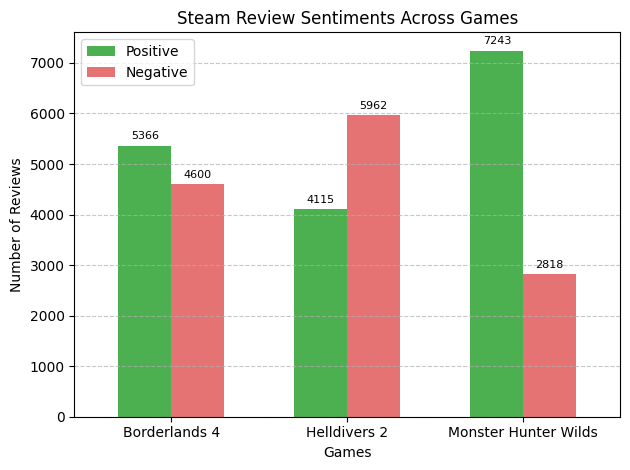

In [7]:
summary_df = merged_reviews.groupby(["game_name", "voted_up"]).size().unstack(fill_value=0)
summary_df = summary_df.rename(
    index={
        "borderlands4": "Borderlands 4",
        "helldivers2": "Helldivers 2",
        "monster_hunter_wilds": "Monster Hunter Wilds",
    }
)
summary_df.columns = ["Negative", "Positive"]

summary_df = summary_df[["Positive", "Negative"]]
ax = summary_df.plot(kind="bar", color=["#4CAF50", "#E57373"], width=0.6)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=8)

plt.title("Steam Review Sentiments Across Games")
plt.ylabel("Number of Reviews")
plt.xlabel("Games")
plt.xticks(rotation=0)  # Keeps game titles upright and readable
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Adds clean background grid lines
plt.tight_layout()

plt.show()

In [8]:
# Downloading local csv file
merged_reviews.to_csv("merged_reviews.csv", index=False)